In [1]:
from __future__ import annotations

import argparse
import os
import sqlite3
import time
from pathlib import Path
from typing import Dict, List, Sequence
import pymc.sampling.jax as pmjax

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v6.0.0


In [ ]:
import pandas as pd
# make sure to change this line to the corresponding location.
df = pd.read_csv("method_rows_export.csv")

In [3]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

OUTCOME_COLUMN = "machine_annotated_tests"
COMPLEXITY_COLUMNS = [
    "wmc",
    "parameters_qty",
    "returns_qty",
    "try_catch_qty",
]
STRUCTURAL_COLUMNS = [
    "fanin",
    "fanout",
]
def zscore_log1p(values):
    """
    1. clip to nonnegative
    2. log1p to compress long tails
    3. z-score standardize columnwise
    """
    arr = np.asarray(values, dtype=float)
    arr = np.clip(arr, 0, None)
    transformed = np.log1p(arr)

    if transformed.ndim == 1:
        mean = np.nanmean(transformed)
        std = np.nanstd(transformed) + 1e-8
        return (transformed - mean) / std

    mean = np.nanmean(transformed, axis=0, keepdims=True)
    std = np.nanstd(transformed, axis=0, keepdims=True) + 1e-8
    return (transformed - mean) / std


def prepare_visibility_full(df):
    df = df.copy()

    for col in ["is_public", "is_private", "is_protected", "is_package"]:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    vis_sum = df[["is_public", "is_private", "is_protected", "is_package"]].sum(axis=1)
    print("Rows with exactly one visibility flag:", (vis_sum == 1).mean())

    # package-private is the omitted reference category
    x_vis = df[["is_public", "is_private", "is_protected"]].values
    return df, x_vis
    
SECONDS_PER_DAY = 24 * 60 * 60
SECONDS_PER_YEAR = 365.25 * SECONDS_PER_DAY

In [4]:
def add_latent_complexity_block(x_complexity):
    n = x_complexity.shape[0]
    k = x_complexity.shape[1]

    Complexity = pm.Normal("Complexity", 0, 1, shape=n)
    
    # WMC anchors the latent scale
    lambda_wmc = 1.0
    
    # Other complexity metrics should load positively onto complexity
    lambda_rest = pm.HalfNormal("lambda_rest", 0.5, shape=k - 1)
    
    lambda_c = pm.Deterministic(
        "lambda_c",
        pm.math.concatenate([pm.math.constant([lambda_wmc]), lambda_rest]),
    )
    
    # Do not estimate WMC residual noise; it is the anchor indicator.
    sigma_wmc = 0.10
    
    # Estimate residual noise only for the other indicators.
    sigma_rest_raw = pm.HalfNormal("sigma_rest_raw", 0.5, shape=k - 1)
    sigma_rest = 0.05 + sigma_rest_raw
    
    sigma_c = pm.Deterministic(
        "sigma_c",
        pm.math.concatenate([pm.math.constant([sigma_wmc]), sigma_rest]),
    )
    
    pm.Normal(
        "complexity_measurement",
        mu=Complexity[:, None] * lambda_c[None, :],
        sigma=sigma_c[None, :],
        observed=x_complexity,
    )
    
    return Complexity
def get_complexity_predictor(inputs, use_latent_complexity=True):
    x_complexity = inputs["X_complexity"]

    if use_latent_complexity:
        complexity_predictor = add_latent_complexity_block(x_complexity)
    else:
        # COMPLEXITY_COLUMNS[0] == "wmc"
        complexity_predictor = x_complexity[:, 0]

    return complexity_predictor

In [5]:
def zscore_array(x, eps=1e-12):
    """
    Z-score a numeric array. If the SD is nearly zero, return zeros.
    """
    x = np.asarray(x, dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)

    if not np.isfinite(sd) or sd < eps:
        return np.zeros_like(x, dtype=float)

    return np.nan_to_num((x - mu) / sd)


def prepare_usage_within_repo(df, usage_raw, repo_col="repo"):
    """
    Repository-mean-center log usage.

    Let:

        x_m = log1p(usage_m)

    Then:

        usage_within_m = x_m - mean(x)_repo(m)

    The returned usage_within_log is z-scored after repo-centering, so the
    coefficient is interpreted per 1 SD increase in within-repo centered log usage.
    """

    x_usage = np.log1p(np.clip(np.asarray(usage_raw, dtype=float), 0, None))

    usage_series = pd.Series(x_usage, index=df.index)
    repo_labels = df[repo_col].astype("category")

    repo_mean_for_method = (
        usage_series
        .groupby(repo_labels, observed=True)
        .transform("mean")
        .to_numpy(dtype=float)
    )

    usage_within_raw = x_usage - repo_mean_for_method

    return {
        # Old pooled usage, kept only for comparison / robustness.
        "usage_log": zscore_array(x_usage),

        # New main predictor.
        "usage_within_log": zscore_array(usage_within_raw),

        # Raw values for checking / plotting.
        "usage_log1p_raw": x_usage,
        "usage_repo_mean_log1p_raw": repo_mean_for_method,
        "usage_within_raw": usage_within_raw,
    }

In [6]:
def prepare_model_inputs(
    df,
    outcome_column=OUTCOME_COLUMN,
    min_age_for_frequency=SECONDS_PER_DAY,
    freq_time_scale=SECONDS_PER_YEAR,
):
    """
    Convert the exported method-level dataframe into the exact arrays used by PyMC.

    Usage predictor:
      - usage_within_log: z-scored repository-mean-centered log1p usage

    History predictors:
      - commit_count_log1p: z-scored log1p raw commit count
      - age_log1p: z-scored log1p raw age
      - commit_freq_log1p: z-scored log1p commit frequency
    """

    df, x_vis = prepare_visibility_full(df)

    # Outcome: test count per method
    y = pd.to_numeric(df[outcome_column], errors="coerce").fillna(0).astype(int).values
    y = np.clip(y, 0, None)

    # Repo index for hierarchical random intercepts
    repo_cat = df["repo"].astype("category")
    repo_idx = repo_cat.cat.codes.values.astype(int)
    n_repos = int(repo_cat.cat.categories.size)

    # Usage predictors
    usage_any = (
        pd.to_numeric(df.get("usage_any", 0), errors="coerce")
        .fillna(0)
        .astype(int)
        .values
    )
    usage_any = np.clip(usage_any, 0, 1)

    usage = (
        pd.to_numeric(df.get("usage", 0), errors="coerce")
        .fillna(0)
        .astype(float)
        .values
    )
    usage = np.clip(usage, 0, None)

    usage_parts = prepare_usage_within_repo(df, usage)

    # Complexity measurement matrix
    x_complexity = (
        df[COMPLEXITY_COLUMNS]
        .replace({",": ""}, regex=True)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .values
    )
    x_complexity = np.clip(x_complexity, 0, None)
    x_complexity_raw = x_complexity.copy()
    x_complexity = zscore_log1p(x_complexity)

    # Repo-local structural connectivity predictors
    x_structural = (
        df[STRUCTURAL_COLUMNS]
        .replace({",": ""}, regex=True)
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0)
        .values
    )
    x_structural = np.clip(x_structural, 0, None)
    x_structural_raw = x_structural.copy()
    x_structural = zscore_log1p(x_structural)

    fanin_log = x_structural[:, 0]
    fanout_log = x_structural[:, 1]

    # History predictors
    commit_count = (
        pd.to_numeric(df.get("commit_count", 0), errors="coerce")
        .fillna(0)
        .astype(float)
        .values
    )
    commit_count = np.clip(commit_count, 0, None)

    age = (
        pd.to_numeric(df.get("age", 0), errors="coerce")
        .fillna(0)
        .astype(float)
        .values
    )
    age = np.clip(age, 0, None)

    commit_count_log1p = zscore_log1p(commit_count)
    age_log1p = zscore_log1p(age)

    # Frequency-history predictor
    age_for_frequency = np.maximum(age, min_age_for_frequency)

    commit_frequency = commit_count / (age_for_frequency / freq_time_scale)
    commit_frequency = np.clip(commit_frequency, 0, None)

    commit_freq_log1p = zscore_log1p(commit_frequency)

    return {
        "df": df,
        "Y": y,

        "repo_idx": repo_idx,
        "n_repos": n_repos,

        "usage_any": usage_any,

        # Old pooled usage predictor, kept for robustness comparison.
        "usage_log": usage_parts["usage_log"],

        # Main usage predictor: within-repository centered usage.
        "usage_within_log": usage_parts["usage_within_log"],

        "X_vis": x_vis,

        "X_complexity": x_complexity,
        "X_complexity_raw": x_complexity_raw,

        "fanin_log": fanin_log,
        "fanout_log": fanout_log,
        "X_structural_raw": x_structural_raw,

        # Raw-history predictors
        "commit_count_log1p": commit_count_log1p,
        "age_log1p": age_log1p,

        # Frequency-history predictor
        "commit_freq_log1p": commit_freq_log1p,

        # Optional raw values for checking / plotting
        "usage_raw": usage,
        "usage_log1p_raw": usage_parts["usage_log1p_raw"],
        "usage_repo_mean_log1p_raw": usage_parts["usage_repo_mean_log1p_raw"],
        "usage_within_raw": usage_parts["usage_within_raw"],

        "commit_count_raw": commit_count,
        "age_raw": age,
        "age_for_frequency_raw": age_for_frequency,
        "commit_frequency_raw": commit_frequency,

        # Metadata
        "min_age_for_frequency": min_age_for_frequency,
        "freq_time_scale": freq_time_scale,
    }

In [7]:
inputs = prepare_model_inputs(
    df,
    outcome_column="machine_annotated_tests",
    min_age_for_frequency=SECONDS_PER_YEAR,
    freq_time_scale=SECONDS_PER_YEAR,
)
def build_any_test_model(
    inputs,
    use_latent_complexity=True,
    use_usage_any=True,
    use_commit_freq=True,
    use_commit_count_age=False,
    use_commit_count_age_interaction=False,
):
    y = inputs["Y"]
    has_test = (y > 0).astype(int)

    repo_idx = inputs["repo_idx"]
    n_repos = inputs["n_repos"]

    x_vis = inputs["X_vis"]
    usage_any = inputs["usage_any"]

    # Main usage predictor:
    # z-scored repository-mean-centered log1p usage
    usage_within_log = inputs["usage_within_log"]

    fanin_log = inputs["fanin_log"]
    fanout_log = inputs["fanout_log"]

    if use_commit_freq and use_commit_count_age:
        raise ValueError(
            "Do not include commit frequency together with commit count and age. "
            "Use either use_commit_freq=True or use_commit_count_age=True."
        )

    if use_commit_freq:
        commit_freq_log1p = inputs["commit_freq_log1p"]

    if use_commit_count_age:
        commit_count_log1p = inputs["commit_count_log1p"]
        age_log1p = inputs["age_log1p"]

        # Standardize before adding main effects and interaction
        commit_count_z = (
            commit_count_log1p - commit_count_log1p.mean()
        ) / commit_count_log1p.std()

        age_z = (
            age_log1p - age_log1p.mean()
        ) / age_log1p.std()

        commit_count_x_age = commit_count_z * age_z

    with pm.Model() as model:
        complexity_predictor = get_complexity_predictor(
            inputs,
            use_latent_complexity=use_latent_complexity,
        )

        # Repository random intercept
        sigma_repo = pm.HalfNormal("sigma_repo", 0.5)
        repo_raw = pm.Normal("repo_raw", 0, 1, shape=n_repos)
        repo_eff = repo_raw * sigma_repo

        alpha = pm.Normal("alpha", 0, 1)

        beta_complexity = pm.Normal("beta_complexity", 0, 0.3)
        beta_vis = pm.Normal("beta_vis", 0, 0.5, shape=x_vis.shape[1])

        beta_usage_within = pm.Normal("beta_usage_within", 0, 0.3)

        beta_fanin = pm.Normal("beta_fanin", 0, 0.3)
        beta_fanout = pm.Normal("beta_fanout", 0, 0.3)

        eta = (
            alpha
            + beta_complexity * complexity_predictor
            + pm.math.dot(x_vis, beta_vis)
            + beta_usage_within * usage_within_log
            + beta_fanin * fanin_log
            + beta_fanout * fanout_log
            + repo_eff[repo_idx]
        )

        if use_usage_any:
            beta_usage_any = pm.Normal("beta_usage_any", 0, 0.3)
            eta = eta + beta_usage_any * usage_any

        if use_commit_freq:
            beta_commit_freq = pm.Normal("beta_commit_freq", 0, 0.3)
            eta = eta + beta_commit_freq * commit_freq_log1p

        if use_commit_count_age:
            beta_commit_count = pm.Normal("beta_commit_count", 0, 0.3)
            beta_age = pm.Normal("beta_age", 0, 0.3)

            eta = (
                eta
                + beta_commit_count * commit_count_z
                + beta_age * age_z
            )

            if use_commit_count_age_interaction:
                beta_commit_count_x_age = pm.Normal(
                    "beta_commit_count_x_age",
                    0,
                    0.2,
                )
                eta = eta + beta_commit_count_x_age * commit_count_x_age

        pm.Bernoulli(
            "has_test",
            logit_p=eta,
            observed=has_test,
        )
    return model

Rows with exactly one visibility flag: 1.0


In [10]:
# Count + age + interaction gate model, without frequency
# model_any_count_age_interaction = build_any_test_model(
#     inputs,
#     use_latent_complexity=True,
#     use_usage_any=False,
#     use_commit_freq=False,
#     use_commit_count_age=True,
#     use_commit_count_age_interaction=True,
# )
# with model_any_count_age_interaction:
#     idata_any_test_within_usage = pmjax.sample_numpyro_nuts(
#         draws=2000,
#         tune=2000,
#         chains=4,
#         target_accept=0.9,
#         random_seed=0,
#         chain_method="sequential",
#         postprocessing_backend="cpu",
#         idata_kwargs={"log_likelihood": False},
#     )

#     idata_any_test_within_usage = pm.compute_log_likelihood(
#         idata_any_test_within_usage,
#         extend_inferencedata=True,
#         progressbar=True,
#     )

# idata_any_test_within_usage.to_netcdf(
#     "idata_any_test_within_usage_with_log.nc"
# )
idata_any_test_within_usage = az.from_netcdf(
    "idata_any_test_within_usage_with_log.nc"
)

In [13]:
import arviz as az
import numpy as np
import pandas as pd

idata = idata_any_test_within_usage
summary = az.summary(
    idata,
    var_names=[
        "alpha",
        "beta_complexity",
        "beta_vis",
        "beta_usage_within",
        "beta_fanin",
        "beta_fanout",
        "beta_commit_count",
        "beta_age",
        "beta_commit_count_x_age",
        "sigma_repo",
    ],
    ci_prob=0.95,
    ci_kind="hdi",
    round_to=3,
)

summary

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
alpha,-1.721,0.273,-2.253,-1.167,814.204,1439.342,1.003,0.010,0.007
beta_complexity,0.274,0.014,0.246,0.301,11435.953,6204.876,1.001,0.000,0.000
beta_vis[0],1.760,0.049,1.665,1.858,6942.291,6552.537,1.000,0.001,0.000
beta_vis[1],-0.020,0.067,-0.150,0.111,7957.220,6740.316,1.000,0.001,0.001
beta_vis[2],0.076,0.071,-0.067,0.217,8741.356,6200.728,1.000,0.001,0.001
beta_usage_within,0.104,0.012,0.081,0.127,15118.107,6515.838,1.001,0.000,0.000
beta_fanin,-0.181,0.013,-0.206,-0.156,14585.421,6313.337,1.000,0.000,0.000
beta_fanout,0.369,0.013,0.343,0.395,12691.376,6385.851,1.000,0.000,0.000
beta_commit_count,0.405,0.027,0.352,0.460,5865.053,6253.911,1.001,0.000,0.000
beta_age,-0.201,0.052,-0.307,-0.100,5201.595,5367.225,1.001,0.001,0.001


In [14]:
with model_any_count_age_interaction:
    idata_any_ppc = pm.sample_posterior_predictive(
        idata_any_test_within_usage,
        var_names=["has_test"],
        random_seed=1,
        extend_inferencedata=True,
    )

Sampling: [has_test]


Output()

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:-- / 0:00:00

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:-- / 0:00:00

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:-- / 0:00:00

...

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━  97% 0:00:01 / 0:00:12

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺  98% 0:00:01 / 0:00:12

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸  99% 0:00:01 / 0:00:12

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 100% 0:00:01 / 0:00:12

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:12

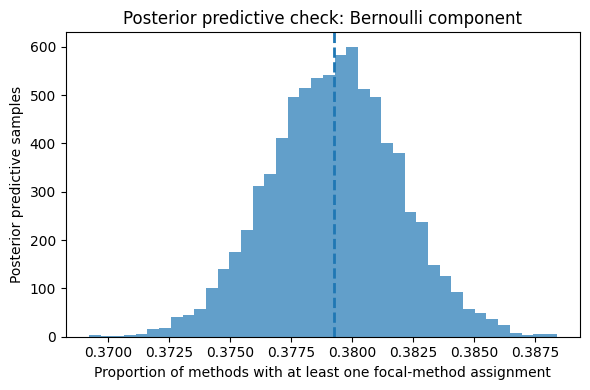

Observed rate: 0.37925369631541894
PPC mean rate: 0.37926024620767634
PPC 95% interval: [0.37404792 0.38448081]


In [15]:
obs_any = idata_any_ppc.observed_data["has_test"].values
ppc_any = idata_any_ppc.posterior_predictive["has_test"].values

# shape: chains x draws x methods -> posterior samples x methods
ppc_any_flat = ppc_any.reshape(-1, ppc_any.shape[-1])

obs_rate = obs_any.mean()
ppc_rates = ppc_any_flat.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.hist(ppc_rates, bins=40, alpha=0.7)
plt.axvline(obs_rate, linestyle="--", linewidth=2)
plt.xlabel("Proportion of methods with at least one focal-method assignment")
plt.ylabel("Posterior predictive samples")
plt.title("Posterior predictive check: Bernoulli component")
plt.tight_layout()
plt.show()

print("Observed rate:", obs_rate)
print("PPC mean rate:", ppc_rates.mean())
print("PPC 95% interval:", np.quantile(ppc_rates, [0.025, 0.975]))

In [17]:
def make_repeated_assignment_tier(
    y_pos,
    return_cutoffs=False,
    quantile_method="nearest",
):
    """
    Quantile-informed ordinal tiers for positive focal-method assignment counts T_m.

    T_m = 1 is kept as its own tier.
    For repeated assignments, T_m > 1, the remaining tiers are informed by
    empirical quantiles of the repeated-count distribution.

    With repeated-count quantiles approximately [q50, q75, q90] = [3, 5, 11],
    this produces:

    0: T_m = 1
    1: 2 <= T_m <= 3
    2: 4 <= T_m <= 5
    3: 6 <= T_m <= 11
    4: T_m > 11
    """
    y_pos = np.asarray(y_pos)

    if np.any(y_pos <= 0):
        raise ValueError("y_pos should contain only positive counts.")

    repeated = y_pos[y_pos > 1]

    if len(repeated) == 0:
        raise ValueError("No repeated assignments found; cannot define repeated tiers.")

    q50, q75, q90 = np.quantile(
        repeated,
        [0.50, 0.75, 0.90],
        method=quantile_method,
    )

    # Integer cutoffs because assignment counts are integer-valued.
    c1 = int(q50)
    c2 = int(q75)
    c3 = int(q90)

    if not (1 < c1 < c2 < c3):
        raise ValueError(
            "Quantile cutoffs are not strictly increasing: "
            f"q50={q50}, q75={q75}, q90={q90}. "
            "Use fixed cutoffs or fewer tiers."
        )

    tier = np.select(
        [
            y_pos == 1,
            (y_pos >= 2) & (y_pos <= c1),
            (y_pos > c1) & (y_pos <= c2),
            (y_pos > c2) & (y_pos <= c3),
            y_pos > c3,
        ],
        [0, 1, 2, 3, 4],
        default=-1,
    )

    if np.any(tier == -1):
        bad = y_pos[tier == -1]
        raise ValueError(f"Some positive counts were not assigned to a tier: {bad}")

    tier = tier.astype(int)

    cutoffs = {
        "q50": q50,
        "q75": q75,
        "q90": q90,
        "tier_0": "T_m = 1",
        "tier_1": f"2 <= T_m <= {c1}",
        "tier_2": f"{c1 + 1} <= T_m <= {c2}",
        "tier_3": f"{c2 + 1} <= T_m <= {c3}",
        "tier_4": f"T_m > {c3}",
    }

    if return_cutoffs:
        return tier, cutoffs

    return tier
y_all = inputs["Y"]
keep = y_all > 0
y_pos = y_all[keep]

tier, cutoffs = make_repeated_assignment_tier(y_pos, True)

print(cutoffs)
np.unique(tier, return_counts=True)

{'q50': np.int64(3), 'q75': np.int64(5), 'q90': np.int64(11), 'tier_0': 'T_m = 1', 'tier_1': '2 <= T_m <= 3', 'tier_2': '4 <= T_m <= 5', 'tier_3': '6 <= T_m <= 11', 'tier_4': 'T_m > 11'}


(array([0, 1, 2, 3, 4]), array([10515,  4115,  1361,  1115,   670]))

In [18]:
def build_positive_ordinal_model(
    inputs,
    use_latent_complexity=True,
    use_usage_any=False,
    use_commit_freq=False,
    use_commit_count_age=True,
    use_commit_count_age_interaction=True,
):
    y_all = inputs["Y"]
    keep = y_all > 0

    y_pos = y_all[keep]
    tier = make_repeated_assignment_tier(y_pos)

    repo_idx = inputs["repo_idx"][keep]
    n_repos = inputs["n_repos"]

    x_vis = inputs["X_vis"][keep]
    usage_any = inputs["usage_any"][keep]
    usage_within_log = inputs["usage_within_log"][keep]

    fanin_log = inputs["fanin_log"][keep]
    fanout_log = inputs["fanout_log"][keep]

    if use_commit_freq:
        commit_freq_log1p = inputs["commit_freq_log1p"][keep]

    if use_commit_count_age:
        commit_count_log1p = inputs["commit_count_log1p"][keep]
        age_log1p = inputs["age_log1p"][keep]

        # Standardize before interaction
        commit_count_z = (
            commit_count_log1p - commit_count_log1p.mean()
        ) / commit_count_log1p.std()

        age_z = (
            age_log1p - age_log1p.mean()
        ) / age_log1p.std()

        commit_count_x_age = commit_count_z * age_z

    n_tiers = int(tier.max() + 1)

    with pm.Model() as model:
        if use_latent_complexity:
            x_complexity_pos = inputs["X_complexity"][keep]
            complexity_predictor = add_latent_complexity_block(x_complexity_pos)
        else:
            complexity_predictor = inputs["X_complexity"][keep, 0]

        # Repository random intercept
        sigma_repo = pm.HalfNormal("sigma_repo", 0.5)
        repo_raw = pm.Normal("repo_raw", 0, 1, shape=n_repos)
        repo_eff = repo_raw * sigma_repo

        # Regression coefficients
        beta_complexity = pm.Normal("beta_complexity", 0, 0.3)
        beta_vis = pm.Normal("beta_vis", 0, 0.5, shape=x_vis.shape[1])

        beta_usage_within = pm.Normal("beta_usage_within", 0, 0.3)
        beta_fanin = pm.Normal("beta_fanin", 0, 0.3)
        beta_fanout = pm.Normal("beta_fanout", 0, 0.3)

        eta = (
            beta_complexity * complexity_predictor
            + pm.math.dot(x_vis, beta_vis)
            + beta_usage_within * usage_within_log
            + beta_fanin * fanin_log
            + beta_fanout * fanout_log
            + repo_eff[repo_idx]
        )

        if use_usage_any:
            beta_usage_any = pm.Normal("beta_usage_any", 0, 0.3)
            eta = eta + beta_usage_any * usage_any

        if use_commit_freq:
            beta_commit_freq = pm.Normal("beta_commit_freq", 0, 0.3)
            eta = eta + beta_commit_freq * commit_freq_log1p

        if use_commit_count_age:
            beta_commit_count = pm.Normal("beta_commit_count", 0, 0.3)
            beta_age = pm.Normal("beta_age", 0, 0.3)

            eta = (
                eta
                + beta_commit_count * commit_count_z
                + beta_age * age_z
            )

            if use_commit_count_age_interaction:
                beta_commit_count_x_age = pm.Normal(
                    "beta_commit_count_x_age",
                    0,
                    0.2,
                )
                eta = eta + beta_commit_count_x_age * commit_count_x_age

        # Ordered cutpoints. No separate intercept is needed because the
        # cutpoints serve as category thresholds.
        cutpoints = pm.Normal(
            "cutpoints",
            mu=np.linspace(-2, 2, n_tiers - 1),
            sigma=1.5,
            shape=n_tiers - 1,
            transform=pm.distributions.transforms.ordered,
            initval=np.linspace(-2, 2, n_tiers - 1),
        )

        pm.OrderedLogistic(
            "assignment_tier",
            eta=eta,
            cutpoints=cutpoints,
            observed=tier,
        )

    return model

In [20]:

# Full robustness model: frequency + count + age + interaction
model_full = build_positive_ordinal_model(
    inputs,
    use_commit_freq=False,
    use_commit_count_age=True,
    use_commit_count_age_interaction=True,
)

# with model_full:
#     idata_positive_full_ordinal = pmjax.sample_numpyro_nuts(
#         draws=2000,
#         tune=2000,
#         chains=4,
#         target_accept=0.9,
#         random_seed=0,
#         chain_method="sequential",
#         postprocessing_backend="cpu",
#         idata_kwargs={"log_likelihood": False},
#     )

# idata_positive_full_ordinal.to_netcdf(
#     "idata_positive_full_ordinal_tier_model.nc"
# )
idata_positive_full_ordinal = az.from_netcdf("idata_positive_full_ordinal_tier_model.nc")

In [21]:
import arviz as az
import pandas as pd
import numpy as np

models = {
    # "Count + age": idata_positive_count_age_ordinal,
    "Full": idata_positive_full_ordinal,
}

coef_order = [
    "beta_complexity",
    "beta_vis[0]",
    "beta_vis[1]",
    "beta_vis[2]",
    "beta_usage_any",
    "beta_usage_within",
    "beta_fanin",
    "beta_fanout",
    # "beta_commit_freq",
    "beta_commit_count",
    "beta_age",
    "beta_commit_count_x_age",
    "sigma_repo",
]

pretty_names = {
    "beta_complexity": "Complexity",
    "beta_vis[0]": "Public",
    "beta_vis[1]": "Private",
    "beta_vis[2]": "Protected",
    "beta_usage_any": "External usage: any",
    "beta_usage_within": "External usage: intensity",
    "beta_fanin": "Fan-in",
    "beta_fanout": "Fan-out",
    "beta_commit_freq": "Commit frequency",
    "beta_commit_count": "Commit count",
    "beta_age": "Age",
    "beta_commit_count_x_age": "Commit count × age",
    "sigma_repo": "Repo random-effect SD",
}

var_names = [
    "beta_complexity",
    "beta_vis",
    "beta_usage_any",
    "beta_usage_within",
    "beta_fanin",
    "beta_fanout",
    "beta_commit_freq",
    "beta_commit_count",
    "beta_age",
    "beta_commit_count_x_age",
    "sigma_repo",
]


def extract_coef_table(idata, model_name):
    """Extract posterior mean, 95% ETI, and exp(beta) for coefficients."""

    available = set(idata.posterior.data_vars)
    rows = []

    for var in var_names:
        if var not in available:
            continue

        summary = az.summary(
            idata,
            var_names=[var],
            ci_prob=0.95,
            kind="stats",
        )

        for idx, row in summary.iterrows():
            coef_name = str(idx).replace(" ", "")

            beta = float(row["mean"])
            beta_low = float(row["eti95_lb"])
            beta_high = float(row["eti95_ub"])

            # For ordered-logistic betas, exp(beta) is an odds ratio.
            # For sigma_repo, exp() is not meaningful.
            if coef_name == "sigma_repo":
                odds_ratio = np.nan
                or_low = np.nan
                or_high = np.nan
            else:
                odds_ratio = np.exp(beta)
                or_low = np.exp(beta_low)
                or_high = np.exp(beta_high)

            rows.append({
                "model": model_name,
                "term": coef_name,
                "label": pretty_names.get(coef_name, coef_name),
                "beta": beta,
                "beta_low": beta_low,
                "beta_high": beta_high,
                "odds_ratio": odds_ratio,
                "or_low": or_low,
                "or_high": or_high,
            })

    return pd.DataFrame(rows)


coef_table = pd.concat(
    [extract_coef_table(idata, name) for name, idata in models.items()],
    ignore_index=True,
)

coef_table["term"] = pd.Categorical(
    coef_table["term"],
    categories=coef_order,
    ordered=True,
)

coef_table = coef_table.sort_values(["term", "model"])

formatted = coef_table.copy()

formatted["β [95% ETI]"] = formatted.apply(
    lambda r: f'{r["beta"]:.3f} [{r["beta_low"]:.3f}, {r["beta_high"]:.3f}]',
    axis=1,
)

formatted["OR [95% ETI]"] = formatted.apply(
    lambda r: "--" if pd.isna(r["odds_ratio"])
    else f'{r["odds_ratio"]:.2f} [{r["or_low"]:.2f}, {r["or_high"]:.2f}]',
    axis=1,
)

wide_table = formatted.pivot(
    index="label",
    columns="model",
    values=["β [95% ETI]", "OR [95% ETI]"],
)

wide_table

,β [95% ETI],OR [95% ETI]
model,Full,Full
label,,
Age,"0.190 [0.028, 0.350]","1.21 [1.03, 1.42]"
Commit count,"0.110 [0.032, 0.190]","1.12 [1.03, 1.21]"
Commit count × age,"0.150 [0.056, 0.250]","1.16 [1.06, 1.28]"
Complexity,"0.230 [0.200, 0.260]","1.26 [1.22, 1.30]"
External usage: intensity,"0.100 [0.077, 0.130]","1.11 [1.08, 1.14]"
Fan-in,"0.047 [0.013, 0.082]","1.05 [1.01, 1.09]"
Fan-out,"0.290 [0.250, 0.320]","1.34 [1.28, 1.38]"
Private,"0.380 [0.160, 0.600]","1.46 [1.17, 1.82]"


In [22]:
import arviz as az
import numpy as np
import pandas as pd

idata = idata_positive_ordinal

coef_vars = [
    "beta_complexity",
    "beta_vis",
    "beta_usage_within",
    "beta_usage_any",
    "beta_fanin",
    "beta_fanout",
    "beta_commit_freq",
    "sigma_repo",
    "cutpoints",
]

coef_vars = [v for v in coef_vars if v in idata.posterior.data_vars]

summary_ord = az.summary(
    idata,
    var_names=coef_vars,
    round_to=3,
)

summary_ord

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta_complexity,0.258,0.015,0.233,0.282,12915.902,6808.921,1.001,0.000,0.000
beta_vis[0],0.354,0.084,0.220,0.490,6311.170,6047.651,1.000,0.001,0.001
beta_vis[1],0.393,0.113,0.213,0.575,7354.719,6593.666,1.000,0.001,0.001
beta_vis[2],0.173,0.118,-0.014,0.361,7770.503,6421.639,1.000,0.001,0.001
beta_usage_within,0.114,0.014,0.092,0.136,15167.648,6167.832,1.000,0.000,0.000
beta_fanin,0.049,0.017,0.021,0.076,14899.026,6543.488,1.001,0.000,0.000
beta_fanout,0.303,0.017,0.275,0.330,13416.847,6907.500,1.000,0.000,0.000
beta_commit_freq,-0.097,0.018,-0.125,-0.068,13438.891,6090.838,1.001,0.000,0.000
sigma_repo,0.694,0.118,0.528,0.900,2073.812,3277.714,1.002,0.003,0.002
cutpoints[0],0.746,0.185,0.449,1.033,1043.192,1908.786,1.002,0.006,0.004


In [23]:
coef_table_ord = summary_ord.copy()

# Detect ETI columns
lb_col = [c for c in coef_table_ord.columns if c.startswith("eti") and c.endswith("_lb")][0]
ub_col = [c for c in coef_table_ord.columns if c.startswith("eti") and c.endswith("_ub")][0]

coef_table_ord["OR_higher_tier"] = np.exp(coef_table_ord["mean"])
coef_table_ord["OR_higher_tier_lb"] = np.exp(coef_table_ord[lb_col])
coef_table_ord["OR_higher_tier_ub"] = np.exp(coef_table_ord[ub_col])

name_map = {
    "beta_complexity": "Complexity",
    "beta_vis[0]": "Public",
    "beta_vis[1]": "Private",
    "beta_vis[2]": "Protected",
    "beta_usage_within": "Usage",
    "beta_usage_any": "UsageAny",
    "beta_fanin": "FanIn",
    "beta_fanout": "FanOut",
    "beta_commit_freq": "CommitFreq",
    "sigma_repo": "Repo SD",
}

coef_table_ord = coef_table_ord.rename(index=name_map)

coef_table_ord[
    [
        "mean",
        lb_col,
        ub_col,
        "OR_higher_tier",
        "OR_higher_tier_lb",
        "OR_higher_tier_ub",
        "ess_bulk",
        "r_hat",
    ]
].round(3)

,mean,eti89_lb,eti89_ub,OR_higher_tier,OR_higher_tier_lb,OR_higher_tier_ub,ess_bulk,r_hat
Complexity,0.258,0.233,0.282,1.294,1.262,1.326,12915.902,1.001
Public,0.354,0.220,0.490,1.425,1.246,1.632,6311.170,1.000
Private,0.393,0.213,0.575,1.481,1.237,1.777,7354.719,1.000
Protected,0.173,-0.014,0.361,1.189,0.986,1.435,7770.503,1.000
Usage,0.114,0.092,0.136,1.121,1.096,1.146,15167.648,1.000
FanIn,0.049,0.021,0.076,1.050,1.021,1.079,14899.026,1.001
FanOut,0.303,0.275,0.330,1.354,1.317,1.391,13416.847,1.000
CommitFreq,-0.097,-0.125,-0.068,0.908,0.882,0.934,13438.891,1.001
Repo SD,0.694,0.528,0.900,2.002,1.696,2.460,2073.812,1.002
cutpoints[0],0.746,0.449,1.033,2.109,1.567,2.809,1043.192,1.002


In [41]:
# Rebuild the exact same model used to fit idata_positive_ordinal

with model_full:
    pm.sample_posterior_predictive(
        idata_positive_ordinal,
        var_names=["assignment_tier"],
        random_seed=1,
        extend_inferencedata=True,
    )

Sampling: [assignment_tier, beta_age, beta_commit_count, beta_commit_count_x_age]


Output()

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% -:--:-- / 0:00:00

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   0% 0:00:14 / 0:00:00

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━   1% 0:00:14 / 0:00:00

...

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺  98% 0:00:01 / 0:00:14

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺  99% 0:00:01 / 0:00:14

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸  99% 0:00:01 / 0:00:14

Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:14

/tmp/ipykernel_2998991/2210218276.py:4: UserWarning: groups {'posterior_predictive'} already exist in the DataTree and will be overwritten. To avoid this, set extend_inferencedata=False.
  pm.sample_posterior_predictive(


In [42]:
import numpy as np
import pandas as pd

idata = idata_positive_full_ordinal

# Observed ordinal outcome
y_obs = idata.observed_data["assignment_tier"].values.ravel()

# Posterior predictive samples
y_rep_da = idata.posterior_predictive["assignment_tier"]

# Convert from xarray to numpy
# Shape is usually: chain x draw x observation
y_rep = y_rep_da.values

# Collapse chain and draw into one posterior-predictive sample dimension
y_rep = y_rep.reshape(-1, y_rep.shape[-1])

print("Observed shape:", y_obs.shape)
print("Posterior predictive shape:", y_rep.shape)

Observed shape: (17776,)
Posterior predictive shape: (8000, 17776)


In [43]:
tiers = np.sort(np.unique(y_obs))

obs_counts = np.array([(y_obs == k).sum() for k in tiers])
rep_counts = np.array([(y_rep == k).sum(axis=1) for k in tiers]).T

obs_props = obs_counts / obs_counts.sum()
rep_props = rep_counts / rep_counts.sum(axis=1, keepdims=True)

ppc_tier_summary = pd.DataFrame({
    "tier": tiers,
    "obs_prop": obs_props,
    "pred_mean_prop": rep_props.mean(axis=0),
    "pred_2.5%": np.quantile(rep_props, 0.025, axis=0),
    "pred_97.5%": np.quantile(rep_props, 0.975, axis=0),
})

ppc_tier_summary

,tier,obs_prop,pred_mean_prop,pred_2.5%,pred_97.5%
0,0,0.591528,0.590196,0.580839,0.599516
1,1,0.231492,0.231490,0.223054,0.239932
2,2,0.076564,0.077158,0.071670,0.082752
3,3,0.062725,0.063212,0.058392,0.068238
4,4,0.037691,0.037945,0.034091,0.041854


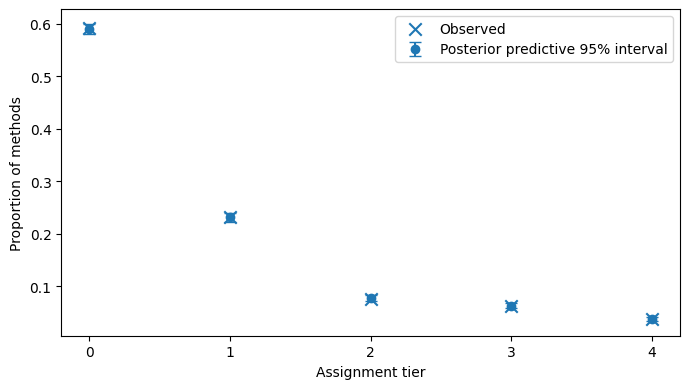

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

x = np.arange(len(tiers))

plt.errorbar(
    x,
    ppc_tier_summary["pred_mean_prop"],
    yerr=[
        ppc_tier_summary["pred_mean_prop"] - ppc_tier_summary["pred_2.5%"],
        ppc_tier_summary["pred_97.5%"] - ppc_tier_summary["pred_mean_prop"],
    ],
    fmt="o",
    capsize=4,
    label="Posterior predictive 95% interval",
)

plt.scatter(
    x,
    ppc_tier_summary["obs_prop"],
    marker="x",
    s=80,
    label="Observed",
)

plt.xticks(x, tiers)
plt.xlabel("Assignment tier")
plt.ylabel("Proportion of methods")
plt.legend()
plt.tight_layout()
plt.show()